# APE 01
# Pasos A Realizar
# 0. Importar Librerias

In [47]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


# Verificar versiones
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12



NumPy: 2.0.2
SciPy: 1.16.3



# Tarea 2: Variables Aleatorias Discretas
# Distribución Binomial




In [48]:
# Parametros de la distribucion binomial
n = 20  #número de ensayos (componentes)
p = 0.05  # probabilidad de éxito (defecto)

# Crear la distribucion binomial
binomial_dist = stats.binom(n, p)


In [49]:
# Valores posibles de la variable aleatoria X (0 a 20 defectos)
x = np.arange(0, n + 1)

# Función de Masa de Probabilidad (PMF)
pmf_values = binomial_dist.pmf(x)

# Mostrar las probabilidades
for i, prob in enumerate(pmf_values):
    print(f"P(X = {i}) = {prob:.6f}")


P(X = 0) = 0.358486
P(X = 1) = 0.377354
P(X = 2) = 0.188677
P(X = 3) = 0.059582
P(X = 4) = 0.013328
P(X = 5) = 0.002245
P(X = 6) = 0.000295
P(X = 7) = 0.000031
P(X = 8) = 0.000003
P(X = 9) = 0.000000
P(X = 10) = 0.000000
P(X = 11) = 0.000000
P(X = 12) = 0.000000
P(X = 13) = 0.000000
P(X = 14) = 0.000000
P(X = 15) = 0.000000
P(X = 16) = 0.000000
P(X = 17) = 0.000000
P(X = 18) = 0.000000
P(X = 19) = 0.000000
P(X = 20) = 0.000000


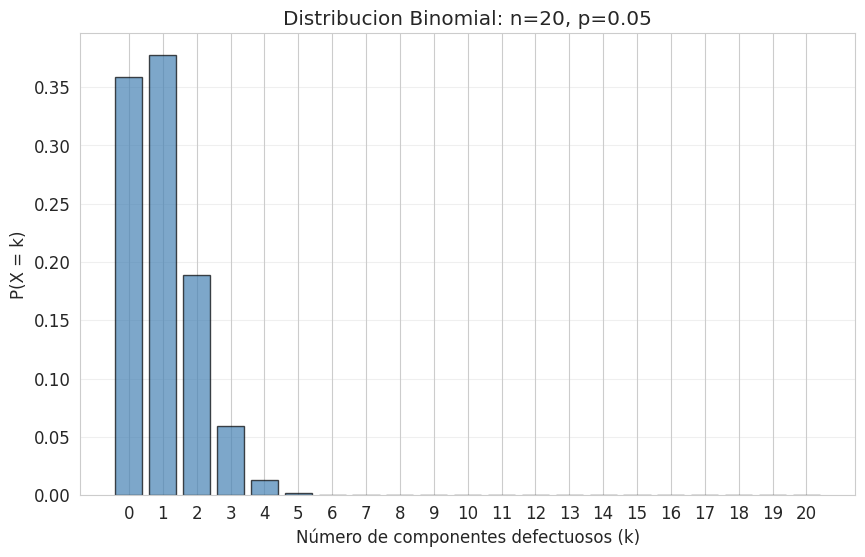

In [50]:
# Grafico de la distribucion binomial
plt.figure(figsize=(10, 6))
plt.bar(x, pmf_values, color="steelblue", edgecolor="black", alpha=0.7)
plt.xlabel("Número de componentes defectuosos (k)")
plt.ylabel("P(X = k)")
plt.title(f"Distribucion Binomial: n={n}, p={p}")
plt.xticks(x)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [51]:
# a) Probabilidad de exactamente 2 defectos
prob_2 = binomial_dist.pmf(2)
print(f"P(X = 2) = {prob_2:.4f}")

# b) Probabilidad de máximo 2 defectos
prob_max_2 = binomial_dist.cdf(2)
print(f"P(X <= 2) = {prob_max_2:.4f}")

# c) Probabilidad de al menos 1 defecto
prob_al_menos_1 = 1 - binomial_dist.cdf(0)
print(f"P(X >= 1) = {prob_al_menos_1:.4f}")


P(X = 2) = 0.1887
P(X <= 2) = 0.9245
P(X >= 1) = 0.6415


In [52]:
# Propiedades teoricas de la distribucion binomial
esperanza = n * p
varianza = n * p * (1 - p)
print(f"Esperanza E[X] = np = {esperanza}")
print(f"Varianza Var(X) = np(1-p) = {varianza:.4f}")
print(f"Desviacion estandar = {np.sqrt(varianza):.4f}")


Esperanza E[X] = np = 1.0
Varianza Var(X) = np(1-p) = 0.9500
Desviacion estandar = 0.9747


# Tarea 3: Variables Aleatorias Continuas
# Distribución Normal

In [54]:
# Parametros de la distribucion normal
mu = 200  # media (ms)
sigma = 30  # desviacion estandar (ms)

# Crear la distribucion normal
normal_dist = stats.norm(loc=mu, scale=sigma)


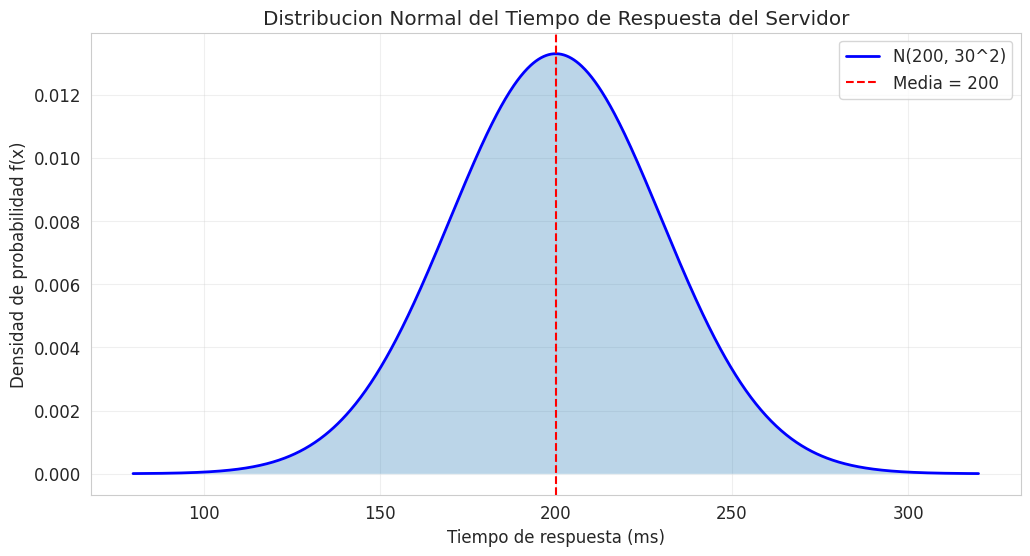

In [55]:
# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Funcion de Densidad de Probabilidad (PDF)
pdf_values = normal_dist.pdf(x)

# Visualizacion
plt.figure(figsize=(12, 6))
plt.plot(x, pdf_values, "b-", linewidth=2, label=f"N({mu}, {sigma}^2)")
plt.fill_between(x, pdf_values, alpha=0.3)
plt.axvline(mu, color="red", linestyle="--", label=f"Media = {mu}")
plt.xlabel("Tiempo de respuesta (ms)")
plt.ylabel("Densidad de probabilidad f(x)")
plt.title("Distribucion Normal del Tiempo de Respuesta del Servidor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [56]:
# a) Probabilidad de tiempo menor a 180 ms
prob_menor_180 = normal_dist.cdf(180)
print(f"P(X < 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) Probabilidad de tiempo entre 170 y 230 ms
prob_entre = normal_dist.cdf(230) - normal_dist.cdf(170)
print(f"P(170 < X < 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# c) Probabilidad de tiempo mayor a 250 ms
prob_mayor_250 = 1 - normal_dist.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")


P(X < 180) = 0.2525 (25.25%)
P(170 < X < 230) = 0.6827 (68.27%)
P(X > 250) = 0.0478 (4.78%)


In [57]:
# Percentiles de la distribucion
p50 = normal_dist.ppf(0.50)  # Mediana
p95 = normal_dist.ppf(0.95)  # Percentil 95
p99 = normal_dist.ppf(0.99)  # Percentil 99

print(f"Percentil 50 (Mediana): {p50:.2f} ms")
print(f"Percentil 95: {p95:.2f} ms")
print(f"Percentil 99: {p99:.2f} ms")

# Interpretacion: El 95% de los tiempos de respuesta son menores a {p95:.2f} ms


Percentil 50 (Mediana): 200.00 ms
Percentil 95: 249.35 ms
Percentil 99: 269.79 ms


# Tarea 4: Simulación y Analisís Comparativo

In [ ]:
# Fijar semilla para reproducibilidad
np.random.seed(42)

# Simular 1000 muestras de la distribucion binomial
muestras_binomial = binomial_dist.rvs(size=1000)

# Simular 1000 muestras de la distribucion normal
muestras_normal = normal_dist.rvs(size=1000)

print(f"Muestras binomiales - Media: {np.mean(muestras_binomial):.2f}, Varianza: {np.var(muestras_binomial):.2f}")
print(f"Muestras normales - Media: {np.mean(muestras_normal):.2f}, Varianza: {np.var(muestras_normal):.2f}")


Muestras binomiales - Media: 0.98, Varianza: 0.95
Muestras normales - Media: 202.97, Varianza: 879.31


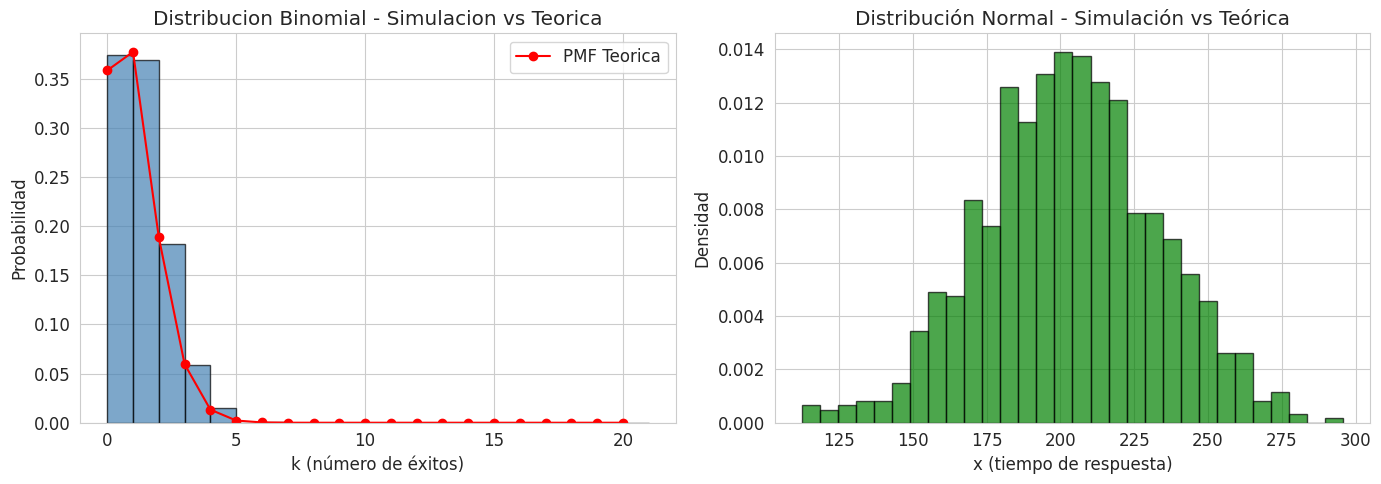

In [61]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Binomial
x_binomial = np.arange(0, n+1)

axes[0].hist(muestras_binomial, bins=range(n+2), density=True,
             alpha=0.7, color="steelblue", edgecolor="black")

axes[0].plot(x_binomial, pmf_values, "ro-", label="PMF Teorica")
axes[0].set_xlabel("k (número de éxitos)")
axes[0].set_ylabel("Probabilidad")
axes[0].set_title("Distribucion Binomial - Simulacion vs Teorica")
axes[0].legend()

# Histograma Normal (sin curva roja)
axes[1].hist(muestras_normal, bins=30, density=True,
             alpha=0.7, color="green", edgecolor="black")

axes[1].set_xlabel("x (tiempo de respuesta)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución Normal - Simulación vs Teórica")

plt.tight_layout()
plt.show()